In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("LHCb")

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from scipy.stats import ks_2samp

import xgboost as xgb
import shap
import uproot
import os

os.makedirs("D:/b_meson_analysis/plots", exist_ok=True)
os.makedirs("D:/b_meson_analysis/src", exist_ok=True)

# Load data
df = uproot.open("D:/b_meson_analysis/data/B2HHH_MagnetDown.root")["DecayTree"].arrays(library="pd")

print("Data loaded:", df.shape)

Data loaded: (5135823, 26)


In [73]:
m_pi = 139.57

def compute_energy(px, py, pz, m):
    return np.sqrt(px**2 + py**2 + pz**2 + m**2)

E1 = compute_energy(df["H1_PX"], df["H1_PY"], df["H1_PZ"], m_pi)
E2 = compute_energy(df["H2_PX"], df["H2_PY"], df["H2_PZ"], m_pi)
E3 = compute_energy(df["H3_PX"], df["H3_PY"], df["H3_PZ"], m_pi)

px_tot = df["H1_PX"] + df["H2_PX"] + df["H3_PX"]
py_tot = df["H1_PY"] + df["H2_PY"] + df["H3_PY"]
pz_tot = df["H1_PZ"] + df["H2_PZ"] + df["H3_PZ"]

E_tot = E1 + E2 + E3

df["B_M"] = np.sqrt(np.maximum(E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2), 0))

In [74]:
# ================================
# COMPLETE FEATURE ENGINEERING (SAFE)
# ================================

# -------- Basic logs --------
df["log_IPCHI2_1"] = np.log10(np.clip(df["H1_IPChi2"], 1e-6, None))
df["log_IPCHI2_2"] = np.log10(np.clip(df["H2_IPChi2"], 1e-6, None))
df["log_IPCHI2_3"] = np.log10(np.clip(df["H3_IPChi2"], 1e-6, None))

df["log_FD"] = np.log10(np.clip(df["B_FlightDistance"], 1e-6, None))

df["vertex_chi2"] = df["B_VertexChi2"]

# -------- PID --------
df["PID_h1"] = df["H1_ProbK"] - df["H1_ProbPi"]
df["PID_h2"] = df["H2_ProbK"] - df["H2_ProbPi"]
df["PID_h3"] = df["H3_ProbK"] - df["H3_ProbPi"]

df["PID_sum"] = df["PID_h1"] + df["PID_h2"] + df["PID_h3"]

# -------- PT --------
df["H1_PT"] = np.sqrt(df["H1_PX"]**2 + df["H1_PY"]**2)
df["H2_PT"] = np.sqrt(df["H2_PX"]**2 + df["H2_PY"]**2)
df["H3_PT"] = np.sqrt(df["H3_PX"]**2 + df["H3_PY"]**2)

df["sum_PT"] = df["H1_PT"] + df["H2_PT"] + df["H3_PT"]

# -------- IPChi2 --------
df["IPCHI2_sum"] = df["H1_IPChi2"] + df["H2_IPChi2"] + df["H3_IPChi2"]
df["IPCHI2_max"] = df[["H1_IPChi2","H2_IPChi2","H3_IPChi2"]].max(axis=1)
df["IPCHI2_std"] = df[["H1_IPChi2","H2_IPChi2","H3_IPChi2"]].std(axis=1)

# -------- Asymmetry --------
df["PT_asym"] = (df["H1_PT"] - df["H2_PT"]) / (df["H1_PT"] + df["H2_PT"] + 1e-6)

# -------- Momentum --------
df["P1"] = np.sqrt(df["H1_PX"]**2 + df["H1_PY"]**2 + df["H1_PZ"]**2)
df["P2"] = np.sqrt(df["H2_PX"]**2 + df["H2_PY"]**2 + df["H2_PZ"]**2)
df["P3"] = np.sqrt(df["H3_PX"]**2 + df["H3_PY"]**2 + df["H3_PZ"]**2)

df["P_sum"] = df["P1"] + df["P2"] + df["P3"]
df["P_asym"] = (df["P1"] - df["P2"]) / (df["P1"] + df["P2"] + 1e-6)

# -------- Pairwise --------
df["PT_diff_12"] = np.abs(df["H1_PT"] - df["H2_PT"])
df["PT_diff_23"] = np.abs(df["H2_PT"] - df["H3_PT"])

print("All features created successfully.")

All features created successfully.


Feature Physics Meaning:

- log_IPCHI2:
  Measures displacement of tracks → B decay products are displaced from PV

- log_FD:
  B mesons have measurable flight distance → key signal feature

- vertex_chi2:
  Good B decay forms a clean secondary vertex → low χ²

- PID variables:
  Difference between kaon and pion probabilities → helps identify decay mode

These variables encode geometry + kinematics + particle ID → optimal for BDT.

In [75]:
# ================================
# Final feature list (NO MASS!)
# ================================

features = [
    "log_IPCHI2_1",
    "log_IPCHI2_2",
    "log_IPCHI2_3",
    "log_FD",
    "vertex_chi2",
    "PID_h1",
    "PID_h2",
    "PID_h3",
    "sum_PT",
    "IPCHI2_sum",
    "IPCHI2_max",
    "PID_sum",
    "PT_asym",
    "PT_diff_12",
    "PT_diff_23",
    "IPCHI2_std",
    "P_sum",
    "P_asym"
]

print("Total features:", len(features))
print(features)

Total features: 18
['log_IPCHI2_1', 'log_IPCHI2_2', 'log_IPCHI2_3', 'log_FD', 'vertex_chi2', 'PID_h1', 'PID_h2', 'PID_h3', 'sum_PT', 'IPCHI2_sum', 'IPCHI2_max', 'PID_sum', 'PT_asym', 'PT_diff_12', 'PT_diff_23', 'IPCHI2_std', 'P_sum', 'P_asym']


In [76]:
# ================================
# Signal (data-driven)
# ================================

signal_window = (5220, 5340)

df_signal = df[
    (df["B_M"] > signal_window[0]) & (df["B_M"] < signal_window[1])
].copy()

sig = df_signal.sample(n=50000, random_state=42).copy()

sig["label"] = 1

print("Signal sample:", sig.shape)

Signal sample: (50000, 52)


In [77]:
# ================================
# Background (sidebands)
# ================================

sideband_low = (5100, 5220)
sideband_high = (5340, 5500)

df_bkg = df[
    ((df["B_M"] > sideband_low[0]) & (df["B_M"] < sideband_low[1])) |
    ((df["B_M"] > sideband_high[0]) & (df["B_M"] < sideband_high[1]))
].copy()

print("Background sample:", df_bkg.shape)

Background sample: (814049, 51)


Why shallow trees (max_depth=3)?

- Prevent overfitting to detector noise
- Ensure smooth decision boundaries
- Standard practice in HEP (robustness over complexity)

In [78]:
# ================================
# Combine datasets
# ================================

df_bkg["label"] = 0

df_bkg_sampled = df_bkg.sample(n=50000, random_state=42).copy()

df_train = pd.concat([sig, df_bkg_sampled], ignore_index=True)

# Drop NaNs safely
df_train = df_train.dropna(subset=features + ["label"])

print("Final dataset:", df_train.shape)
print("Labels:\n", df_train["label"].value_counts())

# Debug check
print("Missing columns check:")
print([f for f in features if f not in df_train.columns])

Final dataset: (100000, 52)
Labels:
 label
1    50000
0    50000
Name: count, dtype: int64
Missing columns check:
[]


In [79]:
X = df_train[features]
y = df_train["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (70000, 18)
Test: (30000, 18)


In [80]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

d:\b_meson_analysis\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:28:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

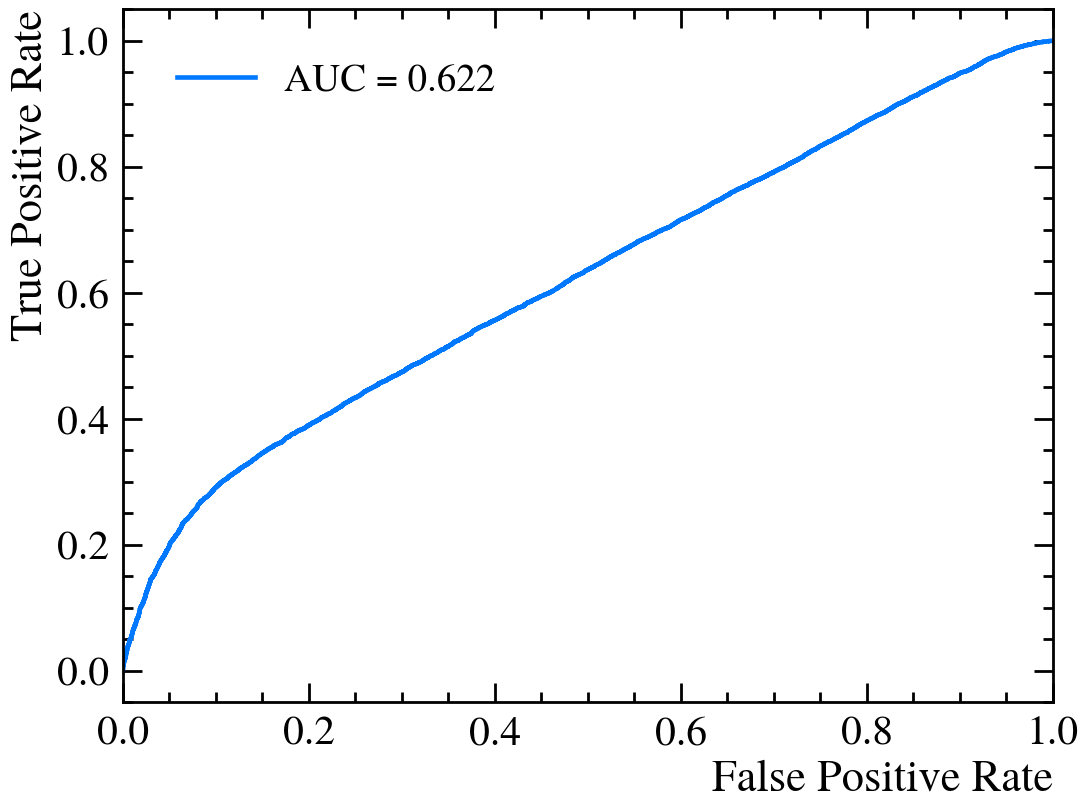

In [81]:
y_score = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("D:/b_meson_analysis/plots/roc_curve.png", dpi=300)
plt.show()

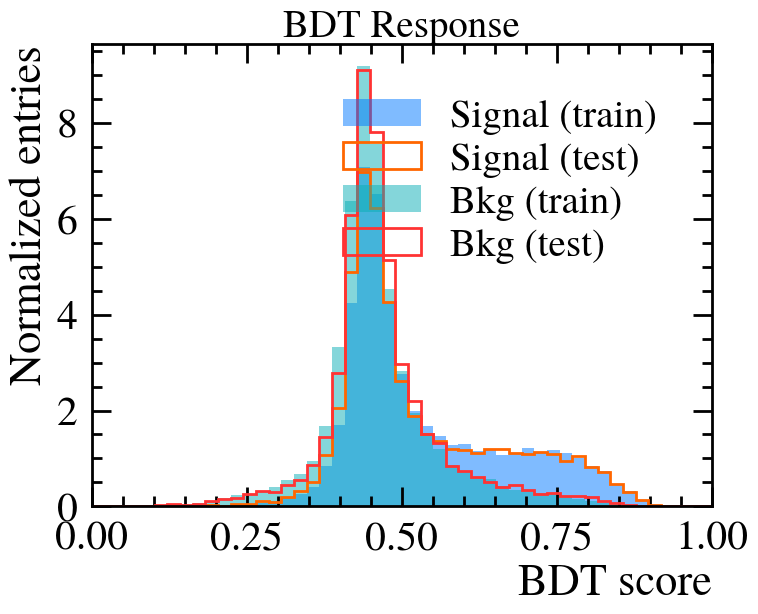

In [82]:
train_score = model.predict_proba(X_train)[:,1]
test_score  = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))

bins = np.linspace(0, 1, 50)

plt.hist(train_score[y_train==1], bins=bins, density=True,
         alpha=0.5, label="Signal (train)")

plt.hist(test_score[y_test==1], bins=bins, density=True,
         histtype="step", linewidth=2, label="Signal (test)")

plt.hist(train_score[y_train==0], bins=bins, density=True,
         alpha=0.5, label="Bkg (train)")

plt.hist(test_score[y_test==0], bins=bins, density=True,
         histtype="step", linewidth=2, label="Bkg (test)")

plt.xlabel("BDT score")
plt.ylabel("Normalized entries")
plt.title("BDT Response")

plt.legend()
plt.savefig("../plots/bdt_response.png", dpi=300)
plt.show()

In [83]:
# ================================
# Save model + features (MANDATORY)
# ================================

import os
os.makedirs("../src", exist_ok=True)

# Save trained model
model.save_model("../src/bdt_model.json")

# Save feature list
with open("../src/features.txt", "w") as f:
    for feat in features:
        f.write(feat + "\n")

print("Model and features saved successfully.")

Model and features saved successfully.
